# Frozen Lake — PPO Training

**Environment:** `FrozenLake-v1` (4×4, deterministic)  
**Algorithm:** Proximal Policy Optimization (PPO-Clip)  

| Symbol | Meaning |
|--------|---------|
| S | Start tile |
| F | Frozen (safe) |
| H | Hole (episode ends, reward = 0) |
| G | Goal (reward = +1) |

**Action space:** `Discrete(4)` — 0 Left · 1 Down · 2 Right · 3 Up  
**Observation space:** `Discrete(16)` — integer `row * ncols + col`

## 1. Imports

In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

print(f"Gymnasium : {gym.__version__}")
print(f"PyTorch   : {torch.__version__}")
print(f"Device    : {'mps' if torch.backends.mps.is_available() else 'cpu'}")

Gymnasium : 1.1.1
PyTorch   : 2.12.0
Device    : mps


## 2. Actor & Critic Networks

Both networks take a **one-hot encoded** state vector (size 16) as input.

| Network | Input | Output | Role |
|---------|-------|--------|------|
| **Actor** | one-hot state (16,) | action probs (4,) | Policy π(a\|s) |
| **Critic** | one-hot state (16,) | scalar V(s) | State-value estimate |

In [2]:
N_STATES  = 16
N_ACTIONS = 4
HIDDEN    = 128


class Actor(nn.Module):
    """Policy network: outputs a probability distribution over actions."""

    def __init__(self, n_states=N_STATES, n_actions=N_ACTIONS,
                 hidden=HIDDEN, lr=3e-4):
        super().__init__()
        self.n_states = n_states
        self.net = nn.Sequential(
            nn.Linear(n_states, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )
        self.optimizer = optim.Adam(self.parameters(), lr=lr)

    def forward(self, state):
        return F.softmax(self.net(state), dim=-1)

    def select_action(self, state):
        """Sample an action; returns (action_int, detached log_prob)."""
        state_oh = F.one_hot(
            torch.tensor(state, dtype=torch.long), num_classes=self.n_states
        ).float()
        # torch.no_grad(): no computation graph needed during data collection
        with torch.no_grad():
            probs = self.forward(state_oh)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        # .detach(): old_log_probs must be a constant in the PPO ratio,
        # not connected to the current parameter graph
        return action.item(), dist.log_prob(action).detach()

    def learn(self, states, actions, old_log_probs, advantages, epsilon=0.2):
        """One PPO-clip gradient step."""
        states_oh = F.one_hot(states, num_classes=self.n_states).float()
        probs = self.forward(states_oh)
        dist = torch.distributions.Categorical(probs)
        new_log_probs = dist.log_prob(actions)


        entropy = dist.entropy().mean()

        ratio = torch.exp(new_log_probs - old_log_probs)
        surr1 = ratio * advantages
        surr2 = torch.clamp(ratio, 1.0 - epsilon, 1.0 + epsilon) * advantages
        loss = -torch.min(surr1, surr2).mean() - (0.05 * entropy)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss.item()


class Critic(nn.Module):
    """Value network: estimates the expected discounted return V(s)."""

    def __init__(self, n_states=N_STATES, hidden=HIDDEN, lr=3e-4):
        super().__init__()
        self.n_states = n_states
        self.net = nn.Sequential(
            nn.Linear(n_states, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )
        self.optimizer = optim.Adam(self.parameters(), lr=lr)

    def forward(self, state):
        return self.net(state)

    def value(self, state):
        """Return V(s) as a plain Python float (no gradient tracked)."""
        state_oh = F.one_hot(
            torch.tensor(state, dtype=torch.long), num_classes=self.n_states
        ).float()
        with torch.no_grad():
            return self.forward(state_oh).item()

    def learn(self, states, returns):
        """One MSE gradient step."""
        states_oh = F.one_hot(states, num_classes=self.n_states).float()
        predicted = self.forward(states_oh).squeeze(-1)
        loss = nn.MSELoss()(predicted, returns)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss.item()


print("Actor and Critic classes defined.")

Actor and Critic classes defined.


## 3. PPO Agent

The `PPOAgent` class owns the Actor and Critic and runs the full PPO loop:

1. **Collect** a fixed-length rollout across multiple episodes
2. **Compute** discounted returns G_t
3. **Normalise** advantages (zero mean, unit std)
4. **Update** Actor and Critic for **K epochs** on the same batch

In [3]:
class PPOAgent:
    """
    Proximal Policy Optimisation agent.

    Parameters
    ----------
    n_states, n_actions : environment dimensions
    hidden              : hidden layer width for both networks
    lr                  : learning rate (Adam) for both networks
    gamma               : discount factor
    epsilon             : PPO clip range
    k_epochs            : gradient updates per collected batch
    rollout_length      : environment steps collected per batch
    """

    def __init__(self, n_states=N_STATES, n_actions=N_ACTIONS,
                 hidden=HIDDEN, lr=3e-4, gamma=0.99, epsilon=0.2,
                 k_epochs=4, rollout_length=512):
        self.actor         = Actor(n_states, n_actions, hidden, lr)
        self.critic        = Critic(n_states, hidden, lr)
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.k_epochs      = k_epochs
        self.rollout_length = rollout_length
        self.n_states      = n_states

    # ------------------------------------------------------------------
    # Private helpers
    # ------------------------------------------------------------------

    def _collect_trajectories(self, env, current_state):
        """Run the current policy for rollout_length steps."""
        buffer = []
        for _ in range(self.rollout_length):
            action, log_prob = self.actor.select_action(current_state)
            value            = self.critic.value(current_state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            buffer.append((current_state, action, float(reward), done, log_prob, value))
            current_state = env.reset()[0] if done else next_state
        return buffer, current_state

    def _compute_returns(self, rewards, dones):
        """Discounted reward-to-go, resetting at episode boundaries."""
        returns, G = [], 0.0
        for reward, done in zip(reversed(rewards), reversed(dones)):
            if done:
                G = 0.0
            G = reward + self.gamma * G
            returns.insert(0, G)
        return torch.tensor(returns, dtype=torch.float32)

    # ------------------------------------------------------------------
    # Public interface
    # ------------------------------------------------------------------

    def train(self, env, n_updates=300, seed=42):
        """
        Run the PPO training loop.
        Returns a history dict: {actor_loss, critic_loss, win_rate}.
        """
        current_state, _ = env.reset(seed=seed)
        history = {"actor_loss": [], "critic_loss": [], "win_rate": []}

        for update in range(1, n_updates + 1):

            # Update pygame window title with current epoch when rendering live
            try:
                import pygame
                if pygame.get_init():
                    pygame.display.set_caption(
                        f"FrozenLake PPO  |  Epoch {update} / {n_updates}"
                    )
            except Exception:
                pass

            # 1. Data collection
            buffer, current_state = self._collect_trajectories(env, current_state)

            states    = torch.tensor([b[0] for b in buffer], dtype=torch.long)
            actions   = torch.tensor([b[1] for b in buffer], dtype=torch.long)
            rewards   = [b[2] for b in buffer]
            dones     = [b[3] for b in buffer]
            log_probs = torch.stack([b[4] for b in buffer])  # already detached
            values    = torch.tensor([b[5] for b in buffer], dtype=torch.float32)

            # 2. Win rate for this batch
            n_done = sum(dones)
            history["win_rate"].append(sum(rewards) / n_done if n_done > 0 else 0.0)

            # 3. Returns and normalised advantages
            returns    = self._compute_returns(rewards, dones)
            advantages = returns - values
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

            # 4. K epochs of PPO updates
            a_losses, c_losses = [], []
            for _ in range(self.k_epochs):
                a_losses.append(
                    self.actor.learn(states, actions, log_probs, advantages, self.epsilon)
                )
                c_losses.append(self.critic.learn(states, returns))

            history["actor_loss"].append(sum(a_losses)  / self.k_epochs)
            history["critic_loss"].append(sum(c_losses) / self.k_epochs)

            if update % 50 == 0:
                print(f"Update {update:4d}/{n_updates} "
                      f"| Win rate: {history['win_rate'][-1]:.2f} "
                      f"| Actor loss: {history['actor_loss'][-1]:8.4f} "
                      f"| Critic loss: {history['critic_loss'][-1]:8.4f}")

        env.close()
        return history

    @staticmethod
    def plot(history):
        """Three-panel training dashboard."""
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle("PPO Training — FrozenLake-v1 (4x4)",
                     fontsize=14, fontweight="bold")
        panels = [
            (axes[0], "win_rate",    "Success Rate",          "Win Rate", "#2ca02c"),
            (axes[1], "critic_loss", "Critic Loss (MSE)",     "Loss",     "#d62728"),
            (axes[2], "actor_loss",  "Actor Loss (PPO-Clip)", "Loss",     "#1f77b4"),
        ]
        for ax, key, title, ylabel, color in panels:
            ax.plot(history[key], color=color, linewidth=2)
            ax.set_title(title, fontsize=12, fontweight="bold")
            ax.set_xlabel("Update Step")
            ax.set_ylabel(ylabel)
            ax.grid(True, alpha=0.3)
            if key == "win_rate":
                ax.set_ylim(-0.05, 1.05)
        plt.tight_layout()
        plt.show()


print("PPOAgent class defined.")

PPOAgent class defined.


## 4. Train

| Parameter | Value |
|-----------|-------|
| `rollout_length` | 512 |
| `k_epochs` | 4 |
| `gamma` | 0.99 |
| `epsilon` | 0.2 |
| `n_updates` | 300 |

## 5. Live Training Window

Runs training inside a **split pygame window**:

| Left pane | Right pane |
|-----------|------------|
| FrozenLake game (live every step) | Stats panel — Epoch, progress bar, Win Rate, Actor Loss, Critic Loss |

Uses `render_mode="rgb_array"` so we control the window ourselves and can draw the side panel.  
Close the window at any time to stop early. Pass `step_delay_ms=50` (or higher) to slow the animation.

In [4]:
import pygame
import numpy as np


class LiveRenderer:
    """
    Pygame window split into:
      - Left  : FrozenLake game frame (rgb_array)
      - Right : stats panel — epoch counter, progress bar, and live
                sparkline charts for Success Rate, Critic Loss, Actor Loss
    """

    PANEL_W  = 320
    BG_COLOR = (18, 18, 28)
    DIV_CLR  = (55, 55, 80)
    CHART_H  = 48   # pixel height of each sparkline

    def __init__(self, game_w: int = 560, game_h: int = 560):
        pygame.init()
        self.game_w = game_w
        self.game_h = game_h
        self.screen = pygame.display.set_mode((game_w + self.PANEL_W, game_h))
        pygame.display.set_caption("FrozenLake — PPO Live Training")
        self.font_xl = pygame.font.SysFont("monospace", 28, bold=True)
        self.font_md = pygame.font.SysFont("monospace", 20, bold=True)
        self.font_sm = pygame.font.SysFont("monospace", 13)

    # ------------------------------------------------------------------

    def draw(self, frame_rgb, update, n_updates, history: dict) -> bool:
        """
        Render game frame + full stats panel.
        Returns False when the user closes the window.
        """
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                return False

        # ── Left pane: game frame ─────────────────────────────────────
        surf = pygame.surfarray.make_surface(np.transpose(frame_rgb, (1, 0, 2)))
        surf = pygame.transform.scale(surf, (self.game_w, self.game_h))
        self.screen.blit(surf, (0, 0))

        # ── Right pane: background + divider ─────────────────────────
        self.screen.fill(self.BG_COLOR,
                         pygame.Rect(self.game_w, 0, self.PANEL_W, self.game_h))
        pygame.draw.line(self.screen, self.DIV_CLR,
                         (self.game_w, 0), (self.game_w, self.game_h), 3)

        x      = self.game_w + 16
        y      = 20
        bar_w  = self.PANEL_W - 32

        # ── Header ───────────────────────────────────────────────────
        self.screen.blit(
            self.font_xl.render("PPO Stats", True, (210, 210, 255)), (x, y))
        y += 42

        # ── Epoch counter ─────────────────────────────────────────────
        epoch_col = (110, 230, 110)
        self._lbl(x, y, "Epoch");  y += 17
        self.screen.blit(
            self.font_md.render(f"{update} / {n_updates}", True, epoch_col), (x, y))
        y += 28

        # Progress bar
        pygame.draw.rect(self.screen, (45, 45, 65), (x, y, bar_w, 11), border_radius=5)
        fill = max(4, int(bar_w * update / n_updates))
        pygame.draw.rect(self.screen, epoch_col, (x, y, fill, 11), border_radius=5)
        pct = self.font_sm.render(f"{100 * update // n_updates}%", True, (155, 155, 180))
        self.screen.blit(pct, (x + bar_w + 5, y))
        y += 26

        # ── Thin divider ──────────────────────────────────────────────
        pygame.draw.line(self.screen, self.DIV_CLR, (x, y + 5), (x + bar_w, y + 5), 1)
        y += 16

        # ── Sparkline charts ──────────────────────────────────────────
        charts = [
            ("Success Rate",  history.get("win_rate",    []), (90,  210, 100), (0.0, 1.0)),
            ("Critic Loss",   history.get("critic_loss", []), (255, 90,  90),  None),
            ("Actor Loss",    history.get("actor_loss",  []), (255, 185, 70),  None),
        ]
        for label, values, color, fixed_range in charts:
            y = self._draw_chart(x, y, bar_w, self.CHART_H,
                                 values, color, label, fixed_range)
            y += 10

        # ── Current numeric values ────────────────────────────────────
        pygame.draw.line(self.screen, self.DIV_CLR, (x, y), (x + bar_w, y), 1)
        y += 10

        def _val_row(label, value, color, fmt):
            nonlocal y
            row = self.font_sm.render(f"{label}: {fmt.format(value)}", True, color)
            self.screen.blit(row, (x, y));  y += 19

        wr = history["win_rate"][-1]   if history["win_rate"]   else 0.0
        al = history["actor_loss"][-1] if history["actor_loss"] else 0.0
        cl = history["critic_loss"][-1] if history["critic_loss"] else 0.0

        wr_col = (90, 200, 255) if wr >= 0.5 else (255, 155, 70)
        _val_row("Win Rate",   wr,  wr_col,         "{:.1%}")
        _val_row("Actor Loss", al,  (255, 185,  70), "{:.4f}")
        _val_row("Crit Loss",  cl,  (255,  90,  90), "{:.4f}")

        pygame.display.flip()
        return True

    # ------------------------------------------------------------------

    def _draw_chart(self, x, y, w, h, values, color, label, fixed_range=None):
        """Draw a labelled sparkline. Returns y below the chart."""
        self._lbl(x, y, label)

        # Current value aligned to the right of the label row
        if values:
            cur = values[-1]
            fmt = f"{cur:.1%}" if fixed_range == (0.0, 1.0) else f"{cur:.4f}"
            cur_surf = self.font_sm.render(fmt, True, color)
            self.screen.blit(cur_surf, (x + w - cur_surf.get_width(), y))

        y += 16

        # Chart background
        pygame.draw.rect(self.screen, (32, 32, 50), (x, y, w, h), border_radius=3)

        if len(values) >= 2:
            if fixed_range:
                mn, mx = fixed_range
            else:
                mn, mx = min(values), max(values)
            rng = max(mx - mn, 1e-8)

            pts = []
            n   = len(values)
            for i, v in enumerate(values):
                px = x + int(i * (w - 1) / max(n - 1, 1))
                py = y + h - 2 - int((v - mn) / rng * (h - 4))
                pts.append((px, py))

            # Subtle filled area under the line
            poly = [(x, y + h), *pts, (x + w - 1, y + h)]
            fill_color = (*color[:3], 40)
            fill_surf  = pygame.Surface((w, h), pygame.SRCALPHA)
            shifted    = [(p[0] - x, p[1] - y) for p in poly]
            pygame.draw.polygon(fill_surf, (*color, 35), shifted)
            self.screen.blit(fill_surf, (x, y))

            pygame.draw.lines(self.screen, color, False, pts, 2)

        return y + h

    def _lbl(self, x, y, text):
        self.screen.blit(self.font_sm.render(text, True, (120, 125, 160)), (x, y))

    def close(self):
        pygame.quit()


# ──────────────────────────────────────────────────────────────────────

def train_live(agent: PPOAgent, env, n_updates: int = 300, seed: int = 42,
               step_delay_ms: int = 0, slow_after: int = 200,
               slow_delay_ms: int = 40) -> dict:
    """
    PPO training loop with a split pygame window (game + charts).

    Parameters
    ----------
    agent          : PPOAgent instance
    env            : gym env created with render_mode="rgb_array"
    n_updates      : total training updates
    seed           : random seed
    step_delay_ms  : base per-step delay in ms (0 = full speed)
    slow_after     : epoch after which the agent slows down for easier viewing
    slow_delay_ms  : per-step delay (ms) applied after slow_after epoch
    """
    renderer         = LiveRenderer()
    current_state, _ = env.reset(seed=seed)
    history          = {"actor_loss": [], "critic_loss": [], "win_rate": []}
    running          = True

    for update in range(1, n_updates + 1):
        if not running:
            break

        # Auto-slowdown after the threshold epoch
        effective_delay = slow_delay_ms if update > slow_after else step_delay_ms

        # ── 1. Collect rollout with live rendering ────────────────────
        buffer = []
        for _ in range(agent.rollout_length):
            action, log_prob = agent.actor.select_action(current_state)
            value            = agent.critic.value(current_state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            buffer.append((current_state, action, float(reward), done, log_prob, value))
            current_state = env.reset()[0] if done else next_state

            frame = env.render()
            if not renderer.draw(frame, update, n_updates, history):
                running = False
                break
            if effective_delay:
                pygame.time.delay(effective_delay)

        # ── 2. Unpack buffer ──────────────────────────────────────────
        states    = torch.tensor([b[0] for b in buffer], dtype=torch.long)
        actions   = torch.tensor([b[1] for b in buffer], dtype=torch.long)
        rewards   = [b[2] for b in buffer]
        dones     = [b[3] for b in buffer]
        log_probs = torch.stack([b[4] for b in buffer])
        values    = torch.tensor([b[5] for b in buffer], dtype=torch.float32)

        # ── 3. Win rate ───────────────────────────────────────────────
        n_done = sum(dones)
        history["win_rate"].append(sum(rewards) / n_done if n_done > 0 else 0.0)

        # ── 4. Returns & advantages ───────────────────────────────────
        returns    = agent._compute_returns(rewards, dones)
        advantages = returns - values
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # ── 5. PPO update ─────────────────────────────────────────────
        a_losses, c_losses = [], []
        for _ in range(agent.k_epochs):
            a_losses.append(
                agent.actor.learn(states, actions, log_probs, advantages, agent.epsilon))
            c_losses.append(agent.critic.learn(states, returns))

        history["actor_loss"].append(sum(a_losses)  / agent.k_epochs)
        history["critic_loss"].append(sum(c_losses) / agent.k_epochs)

        if update % 50 == 0:
            print(f"Update {update:4d}/{n_updates}"
                  f"  win={history['win_rate'][-1]:.2f}"
                  f"  a_loss={history['actor_loss'][-1]:.4f}"
                  f"  c_loss={history['critic_loss'][-1]:.4f}"
                  + ("  [slow]" if update > slow_after else ""))

    env.close()
    renderer.close()
    return history


print("LiveRenderer and train_live defined.")

LiveRenderer and train_live defined.


/Users/juansebastianvargastorres/UTS/Study/frozen-lake/.venv/lib/python3.14/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Update   50/1000  win=0.97  a_loss=-0.0321  c_loss=0.0249
Update  100/1000  win=0.99  a_loss=-0.0263  c_loss=0.0034
Update  150/1000  win=1.00  a_loss=-0.0196  c_loss=0.0092
Update  200/1000  win=1.00  a_loss=-0.0206  c_loss=0.0072
Update  250/1000  win=1.00  a_loss=-0.0208  c_loss=0.0023
Update  300/1000  win=0.99  a_loss=-0.0237  c_loss=0.0153
Update  350/1000  win=1.00  a_loss=-0.0174  c_loss=0.0111
Update  400/1000  win=1.00  a_loss=-0.0202  c_loss=0.0066
Update  450/1000  win=1.00  a_loss=-0.0245  c_loss=0.0101
Update  500/1000  win=1.00  a_loss=-0.0302  c_loss=0.0001
Update  550/1000  win=0.99  a_loss=-0.0181  c_loss=0.0135
Update  600/1000  win=1.00  a_loss=-0.0287  c_loss=0.0001
Update  650/1000  win=1.00  a_loss=-0.0233  c_loss=0.0023
Update  700/1000  win=1.00  a_loss=-0.0247  c_loss=0.0064
Update  750/1000  win=1.00  a_loss=-0.0235  c_loss=0.0064
Update  800/1000  win=1.00  a_loss=-0.0194  c_loss=0.0047
Update  850/1000  win=1.00  a_loss=-0.0252  c_loss=0.0031
Update  900/10

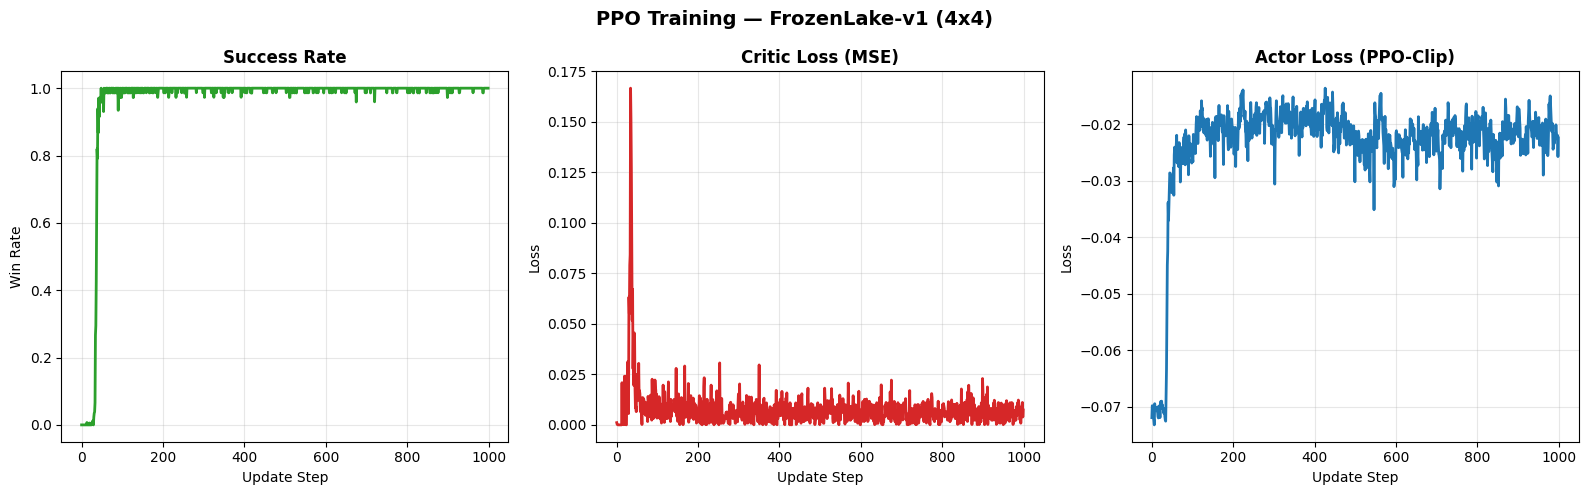

: 

In [ ]:
from gymnasium.envs.toy_text.frozen_lake import generate_random_map

gym.make('FrozenLake-v1', desc=generate_random_map(size=8))

# env_live = gym.make("FrozenLake-v1", map_name="10x10", is_slippery=True,
#                     render_mode="rgb_array")


env_live = gym.make("FrozenLake-v1", desc=generate_random_map(size=8), is_slippery=False,
                    render_mode="rgb_array")

agent_live = PPOAgent(
    n_states=64, n_actions=4, hidden=128,
    lr=1e-3, gamma=0.99, epsilon=0.2,
    k_epochs=10, rollout_length=1024,
)

# Trains at full speed until epoch 200, then slows to 40 ms/step so you
# can clearly watch the trained agent navigate the grid.
history_live = train_live(
    agent_live, env_live,
    n_updates=1000, seed=42,
    step_delay_ms=0,    # epochs 1-200: as fast as possible
    slow_after=995,     # start slowing down after this epoch
    slow_delay_ms=40,   # 40 ms per step once slow mode kicks in
)

PPOAgent.plot(history_live)